<a href="https://colab.research.google.com/github/mirzulqarnain/Convolutional-Neural-Networks/blob/main/Data_augumentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential,preprocessing
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [9]:
img =image.load_img("/content/girl.png" ,target_size = (200,200))

In [10]:
type(img)

PIL.Image.Image

In [31]:
from textwrap import fill
datagen = ImageDataGenerator(
rotation_range=30,
shear_range=0.2,
zoom_range=0.2,
horizontal_flip=True,
width_shift_range=0.2,
height_shift_range=0.2,
fill_mode="nearest"
)

In [32]:
img = image.img_to_array(img)

In [17]:
img.shape

(200, 200, 3)

In [33]:
input_batch = img.reshape((1,200,200,3))

In [34]:
!mkdir -p aug

In [35]:
import os
os.makedirs("aug", exist_ok=True)

In [36]:
i = 0

for output in datagen.flow(
    input_batch,
    batch_size=1,
    save_to_dir="aug",
    save_prefix="augmented",
    save_format="png"
):
    i += 1
    if i == 10:
        break

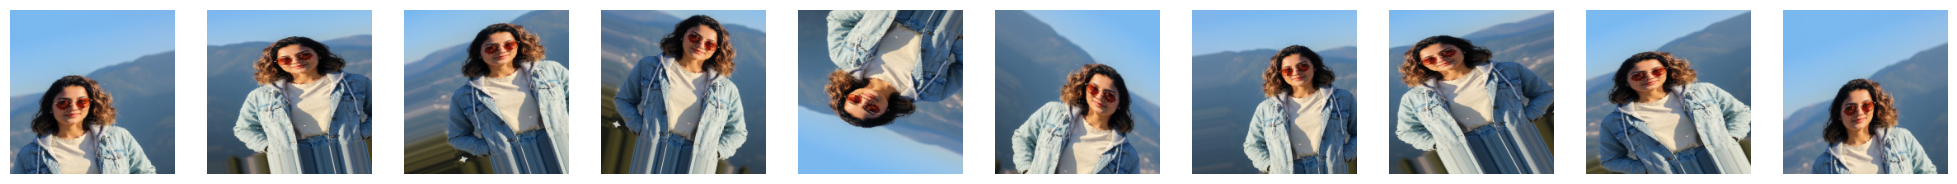

In [37]:
import matplotlib.pyplot as plt

from PIL import Image

files = sorted(os.listdir("aug"))

plt.figure(figsize=(25, 4))
for i, file in enumerate(files[:10]):
    plt.subplot(1, 10, i + 1)   # 1 row, 10 columns
    plt.imshow(Image.open(os.path.join("aug", file)))
    plt.axis("off")
plt.show()

NOW USING PRETRAINED MODELS


In [1]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow. keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

In [2]:
model = ResNet50(weights='imagenet')

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
img_path = '/content/image.jpg'
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

In [8]:
preds = model.predict(x)
print('Predicted:',decode_predictions(preds, top=3)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted: [('n02108422', 'bull_mastiff', np.float32(0.8394262)), ('n02109525', 'Saint_Bernard', np.float32(0.081314094)), ('n02108089', 'boxer', np.float32(0.03623149))]
